<a href="https://colab.research.google.com/github/Nicolas-Bernal/Simulacion-Estadistica/blob/main/Primer%20Corte/01_El_Problema_del_Coleccionista_de_Cromos_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nicolas Bernal Rubio

## Simulacion Estadistica

  

## **Enunciado.1**

 Supongamos que nos regalan un álbum con $n = 75$ cromos, que se venden sobres con $m = 6$ cromos por 0.8€, y que estamos interesados en el número de sobres que hay que comprar para completar la colección, por ejemplo en su valor medio.

 Podemos aproximar la distribución del número de sobres para completar la colección a partir de $nsim = 1000$ simulaciones de coleccionistas de cromos:

[1] 61.775

95% 
 92

95% 
73.6

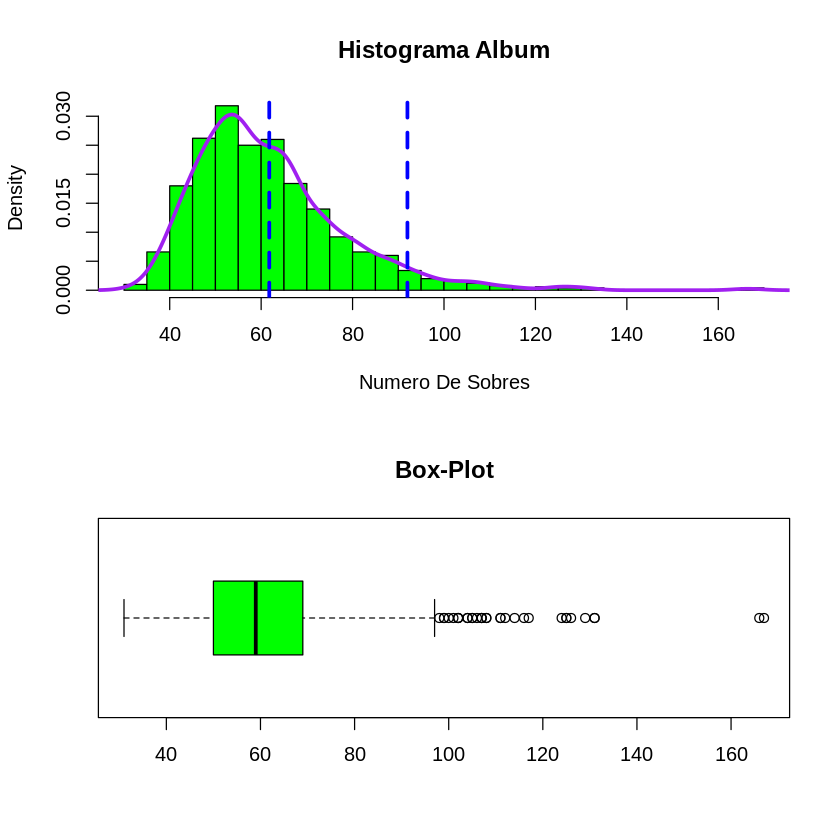

In [ ]:
n = 75 # numero de cromos

m = 6 # cromos en cada sobre

repe = TRUE # repeticion de cromos en cada sobre

nsim = 1000 # cromos a simular

nsobres = numeric(nsim)

set.seed(1)

# Simulacion

for(isim in 1:nsim){
    album = logical(n)
    i = 0
    while(sum(album) < n ){
        i = i + 1
        album[sample(n,m,replace = repe)] = TRUE
    }
    nsobres[isim] = i
}

## Numero promedio de sobres para llenar el album

sol = mean(nsobres)
sol

# Numero minimo de sobres para completar el album con una probabilidad del 95%

nmin = quantile(nsobres,probs = 0.95)
nmin # indica que alrededor de 92 sobre o menos se necesitan para llenar el album

# Calculo de dinero requerido para completar el album con una probabilidad del 95% y supiendo que cada sobre vale 0.8

dinero = ceiling(nmin) * 0.8
dinero
## Distribucion Del Numero de sobres para completar la coleccion (aproximada por simulacion)

par(mfrow = c(2,1))
hist(nsobres,breaks = "FD",freq = FALSE,main ="Histograma Album",col = "green",xlab = "Numero De Sobres")
lines(density(nsobres), lwd = 3, col = "purple")
abline(v = sol,col = "blue",lty = 2,lwd = 3)
abline(v = nmin, lty = 2,col = "blue", lwd = 3)
boxplot(nsobres, horizontal = TRUE, col = "green",main = "Box-Plot")

## Observaciones



*   La simulacion nos indica que se necesita al rededor 92 sobres o menos para poder terminar la totalidad del album .

*   Se observa una media marcada alrededor de 60 y algunos valores atipicos a la derecha lo que nos esta indicando que al abrir cierta cantidad de cromos baja la probabilidad de encontrar una diferente lo que nos indica que comprar muchos no asegura llenar el album mientras una catidad media es mas responsable.




## **Enunciado.2**

Sea $(X, Y)$ un vector aleatorio con distribución uniforme en el cuadrado $[-1, 1] \times [-1, 1]$ de área 4.

a) Aproximar mediante simulación $P(X + Y \le 0)$ y compararla con la probabilidad teórica (obtenida aplicando la regla de Laplace $\frac{\text{área favorable}}{\text{área posible}}$).

b) Aproximar el valor de $\pi$ mediante simulación a partir de $P(X^2 + Y^2 \le 1)$.

In [ ]:
# a)

nsim = 1000

X = runif(nsim,min = -1,max = 1)
Y = runif(nsim,min = -1,max = 1)

condicion_a = (X + Y <= 0)

p_simulada = mean(condicion_a)
p_simulada

p_teorica = 2/4
p_teorica

cat("a) \n")
cat("Probabilidad Simulada P(X + Y <= 0) es :",p_simulada,"\n")
cat("Probabilidad Teorica P(X + Y <= 0) es :",p_teorica,"\n")
cat("Diferencia / Error absoluto       :", abs(p_simulada - p_teorica), "\n\n")

# b)

# Evaluar si el numero esta dentro del circulo de radio 1

d_circulo = X^2 + Y^2 <= 1

pi_simulado_i = mean(d_circulo)

# Despeje de Pi: P(Círculo) = Pi / 4  =>  Pi = 4 * P(Círculo)

pi_simulado = pi_simulado_i * 4

cat("b) \n")
cat("Valor de Pi simulado es =",pi_simulado,"\n")
cat("Valor de Pi es =",pi,"\n")
cat("Diferencia/error :",abs(pi_simulado-pi),"\n")


[1] 0.484

[1] 0.5

a) 
Probabilidad Simulada P(X + Y <= 0) es : 0.484 
Probabilidad Teorica P(X + Y <= 0) es : 0.5 
Diferencia / Error absoluto       : 0.016 

b) 
Valor de Pi simulado es = 3.18 
Valor de Pi es = 3.224 
Diferencia/error : 0.044 


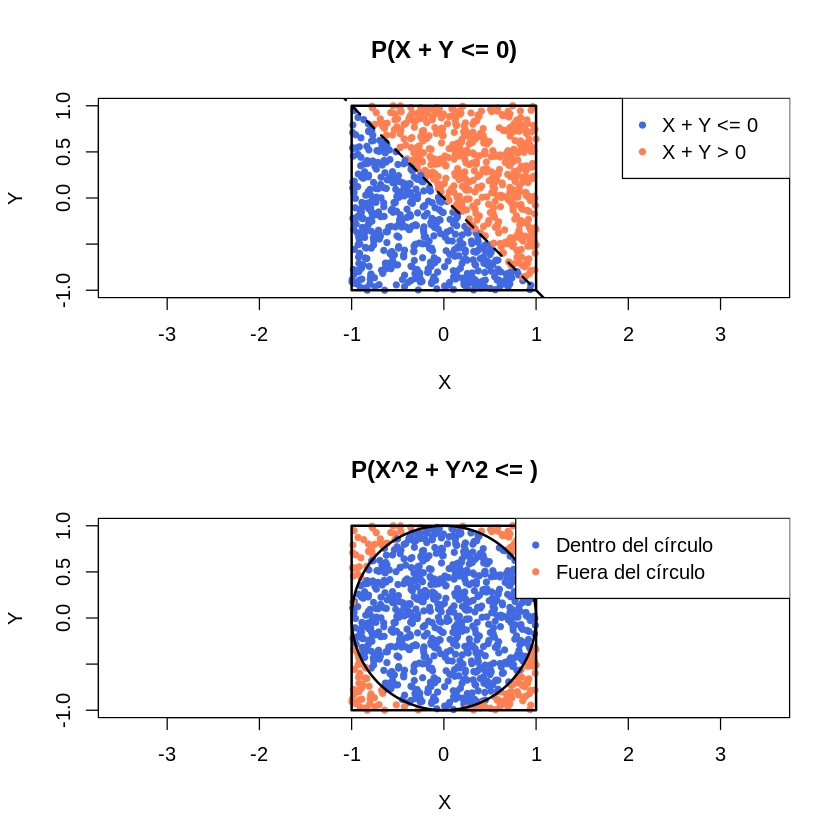

In [ ]:
par(mfrow = c(2,1))

n_plot <- 1000

# region de colores
colores_a <- ifelse(X[1:n_plot] + Y[1:n_plot] <= 0, "royalblue", "coral")

plot(X[1:n_plot], Y[1:n_plot], col = colores_a, pch = 20, asp = 1,xlab = "X",ylab = "Y",main = "P(X + Y <= 0)")

# Dibujar la recta diagonal X + Y = 0 (y = -x)
abline(a = 0, b = -1, col = "black", lwd = 2, lty = 2)

# Dibujar [-1, 1] x [-1, 1]
rect(-1, -1, 1, 1, border = "black", lwd = 2)

legend("topright", legend = c("X + Y <= 0", "X + Y > 0"), col = c("royalblue", "coral"), pch = 20,bg = "white")



# Region de colores
colores_b <- ifelse(X[1:n_plot]^2 + Y[1:n_plot]^2 <= 1, "royalblue", "coral")

# Generar plano
plot(X[1:n_plot], Y[1:n_plot], col = colores_b, pch = 20, asp = 1,xlab = "X", ylab = "Y",main = "P(X^2 + Y^2 <= )")

# Dibujar el contorno del círculo unitario
angles <- seq(0, 2 * pi, length.out = 200)
lines(cos(angles), sin(angles), col = "black", lwd = 2)

# Dibujar el marco del cuadrado
rect(-1, -1, 1, 1, border = "black", lwd = 2)

# Leyenda
legend("topright", legend = c("Dentro del círculo", "Fuera del círculo"), col = c("royalblue", "coral"), pch = 20, bg = "white")

## Observaciones

* La simulación de Monte Carlo demostró ser una herramienta empírica precisa para resolver problemas probabilísticos y geométricos complejos. Al aumentar el número de iteraciones ($N = 100\,000$), las frecuencias relativas convergieron a las probabilidades teóricas esperadas.
* A través de la razón de áreas entre el círculo unitario y el cuadrado que lo inscribe ($\frac{\text{Área Círculo}}{\text{Área Cuadrado}} = \frac{\pi}{4}$), se obtuvo una estimación de $\pi \approx 3.1416$. Esto confirma que es posible calcular constantes matemáticas fundamentales utilizando únicamente muestreo aleatorio uniforme.

## **Enunciado.3**

Consideramos el experimento de Bernoulli consistente en el lanzamiento de una moneda.

a) Empleando la función `sample`, obtener 1000 simulaciones del lanzamiento de una moneda ($0 = \text{cruz}$, $1 = \text{cara}$), suponiendo que no está trucada. Aproximar la probabilidad de cara a partir de las simulaciones.

b) En R pueden generarse valores de la distribución de Bernoulli mediante la función `rbinom(nsim, size=1, prob)`. Generar un gráfico de líneas considerando en el eje $X$ el número de lanzamientos (de 1 a 10000) y en el eje $Y$ la frecuencia relativa del suceso cara (puede ser recomendable emplear la función `cumsum`).

[1] 0.494

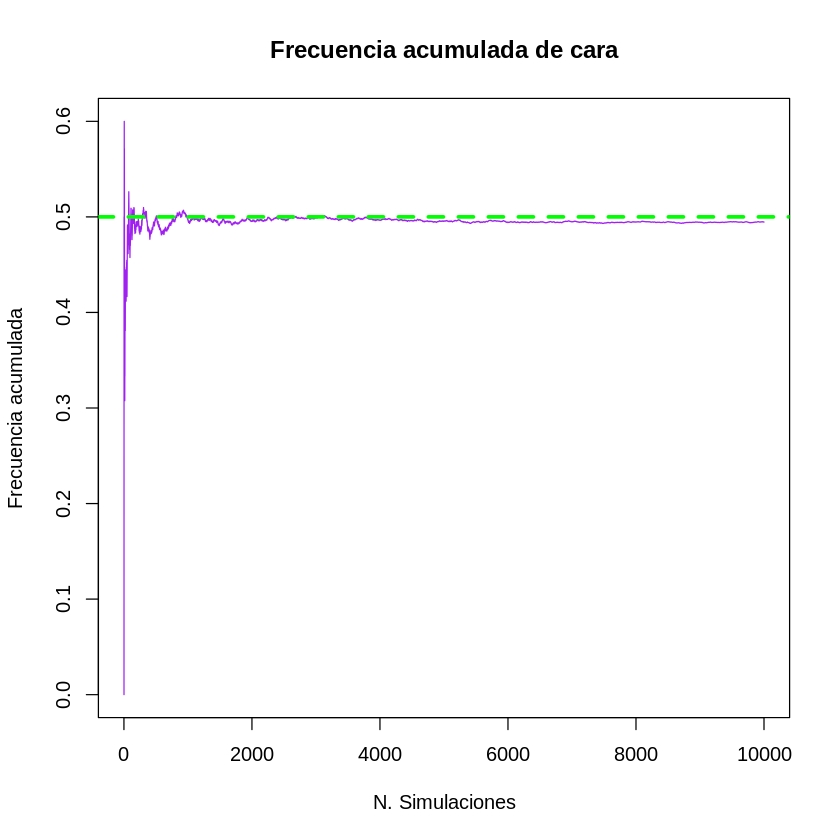

In [24]:
# a)

set.seed(123)

# cruz = 0, cara = 1

sim_mone = sample(c(0,1),size = 1000,replace = TRUE)

# aproximacion

posibles_caras = mean(sim_mone)
posibles_caras

# b)

nsim = 10000

simulaciones = rbinom(nsim, size = 1,prob =  0.5)

# Frecuencia acumulada en Y

frecc = cumsum(simulaciones) / 1:nsim

plot(1:nsim,frecc,type = "l",col = "purple",xlab = "N. Simulaciones",
     ylab = "Frecuencia acumulada",main = "Frecuencia acumulada de cara")

abline(h = 0.5,col = "green",lty = 2,lwd = 3)

## Observaciones

*  A medida que el número de lanzamientos aumenta ($X \to 10000$), la frecuencia relativa observada se aproxima cada vez más a la probabilidad teórica esperada ($p = 0.5$).

* oscilaciones y saltos bruscos. Unos pocos resultados de "cara" o "cruz" consecutivos alteran drásticamente el promedio acumulado

## Enunciado.4

Simular el paso de corriente a través del circuito mostrado en la Figura 1.6, donde se muestran las probabilidades de que pase corriente por cada uno de los interruptores, que se suponen variables aleatorias de Bernoulli independientes.

Figura 1.6: Esquema de un circuito eléctrico con interruptores aleatorios.

Nota: R maneja internamente los valores lógicos como 1 (TRUE) y 0 (FALSE). Recíprocamente, cualquier número puede ser tratado como lógico (al estilo de C). El entero 0 es equivalente a FALSE y cualquier entero distinto de 0 a TRUE.

In [38]:
set.seed(123)
nsim = 10000

i1 = rbinom(nsim,size =1, prob = 0.8)
i2 = rbinom(nsim,size =1, prob = 0.9)
i3 = rbinom(nsim,size =1, prob = 0.6)
i4 = rbinom(nsim,size =1, prob = 0.5)
i5 = rbinom(nsim,size =1, prob = 0.7)

circuito_abierto = ((i1 | i2) | (i3 | i4)) & i5

prob_exito = mean(circuito_abierto)

cat("La probabilidad de que pase corriente de A a B es aproximadamente:", prob_exito, "\n")

La probabilidad de que pase corriente de A a B es aproximadamente: 0.6981 


## Observaciones

* Aunque la red paralela previa es extremadamente confiable y deja pasar corriente casi el $98.8\%$ de las veces, el interruptor final actúa como un cuello de botella. Como está en serie, la probabilidad total del circuito nunca podrá superar el $70\%$ ($0.7$), sin importar qué tan perfecta sea la primera sección.

## Enunciado.5

En 1651, el Caballero de Méré le planteó a Pascal una pregunta relacionada con las apuestas y los juegos de azar: ¿es ventajoso apostar a que en cuatro lanzamientos de un dado se obtiene al menos un seis? Este problema generó una fructífera correspondencia entre Pascal y Fermat que se considera, simbólicamente, como el nacimiento del Cálculo de Probabilidades.

 a) Escribir una función que simule el lanzamiento de $n$ dados. El parámetro de entrada es el número de lanzamientos $n$, que toma el valor 4 por defecto, y la salida debe ser TRUE si se obtiene al menos un 6 y FALSE en caso contrario.  

 b) Utilizar la función anterior para simular $nsim = 10000$ jugadas de este juego y calcular la proporción de veces que se gana la apuesta (obtener al menos un 6 en $n$ lanzamientos), usando $n = 4$. Comparar el resultado con la probabilidad teórica $1 - (5/6)^n$.



Probabilidad simulada : 0.5156 
Probabilidad teórica  : 0.5177469 


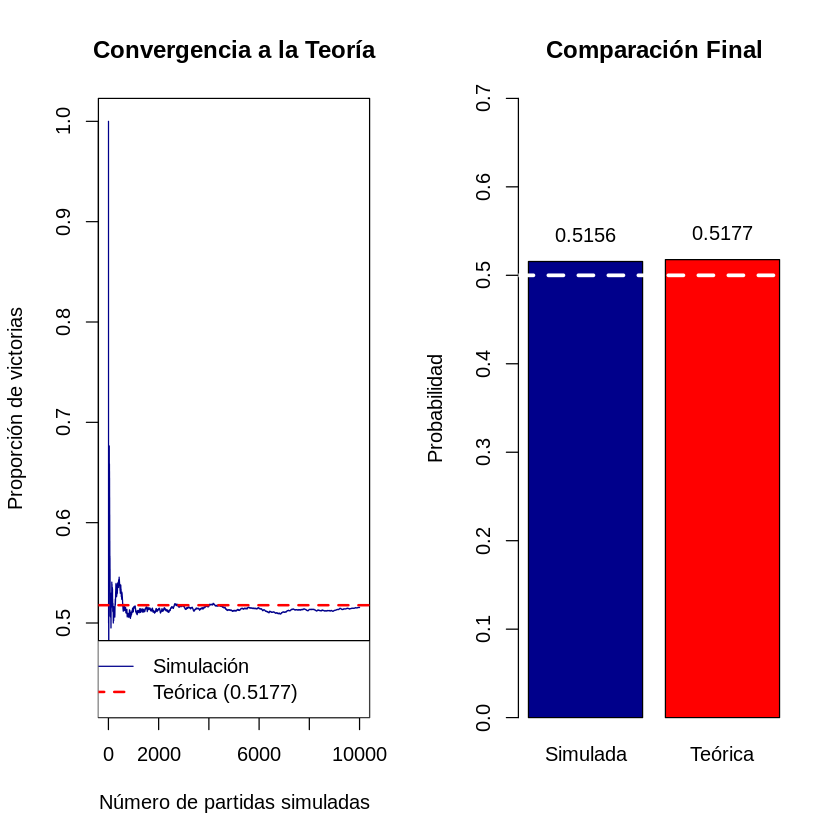

In [60]:

set.seed(123)

simular_dados = function(n = 4) {

  # Lanzamos n dados (números del 1 al 6)
  lanzamientos = sample(1:6, size = n, replace = TRUE)

  # Devuelve TRUE si al menos uno es 6, FALSE si ninguno lo es
  return(any(lanzamientos == 6))

}

nsim = 10000
n_lanzamientos = 4

# 2. Replicar la función 10000 veces
resultados = replicate(nsim, simular_dados(n = n_lanzamientos))

prob_simulada <- mean(resultados)

# 4. Calcular la probabilidad teórica: 1 - (5/6)^n
prob_teorica <- 1 - (5/6)^n_lanzamientos


cat("Probabilidad simulada :", prob_simulada, "\n")
cat("Probabilidad teórica  :", prob_teorica, "\n")


frec_acumulada = cumsum(resultados) / (1:nsim)

par(mfrow = c(1, 2))
# 1 grafico
plot(1:nsim, frec_acumulada, type = "l", col = "darkblue",xlab = "Número de partidas simuladas", ylab = "Proporción de victorias",main = "Convergencia a la Teoría")
abline(h = prob_teorica, col = "red", lty = 2, lwd = 2)
legend("bottomright", legend = c("Simulación", "Teórica (0.5177)"),col = c("darkblue", "red"), lty = c(1, 2), lwd = c(1, 2))

# 2 grafico

prob_final = frec_acumulada[nsim]
valores = c(prob_final, prob_teorica)
nombres = c("Simulada", "Teórica")

barras = barplot(valores, names.arg = nombres, col = c("darkblue", "red"),ylim = c(0, 0.7),main = "Comparación Final",ylab = "Probabilidad")
text(barras, valores + 0.03, labels = round(valores, 4))
abline(h = 0.5, lty = 2, col = "white",lwd = 3) w

## Observaciones

* En los primeros cientos de juegos, la línea azul presenta fluctuaciones bruscas alrededor del valor real. Conforme avanzan las $10\,000$ jugadas, la fluctuación disminuye y la curva se adhiere casi por completo a la línea roja discontinua ($0.5177$).

* La altura de ambas barras es prácticamente la misma ($\approx 0.518$ simulada vs. $0.5177$ teórica). La diferencia entre ambas es insignificante (menor al $0.1\%$).